# Multi-Agent Travel Planner with Human-in-the-Loop [Complete Project]

> **MLCourse - Agentic AI - Travel Planner**

A complete multi-agent travel planner that takes user preferences and generates
a personalized travel itinerary with human approval.

## What you'll learn
- Multi-agent architecture with LangGraph
- Research agent that finds attractions, hotels, restaurants
- Planning agent that creates day-by-day itineraries
- Human-in-the-loop approval with interrupt/resume
- Complete end-to-end pipeline

## When to use this technique
- When you need multiple specialized agents working together
- When human oversight is required before final output
- When building complex workflows with approval gates

In [1]:
# ---- cell 1: setup and imports ----
import os, sys
from pathlib import Path
from typing import TypedDict, Annotated, List, Dict, Any
from dotenv import load_dotenv

# ---- project path discovery ----
def find_track(depth=4):
    p = Path.cwd()
    for _ in range(depth):
        if (p / "03_agentic_ai").is_dir():
            return p
        p = p.parent
    return Path.cwd()

PROJECT = find_track()
DATA = PROJECT / "03_agentic_ai" / "data"
load_dotenv(PROJECT / ".env", override=False)

# ---- LLM setup ----
from langchain_ollama import ChatOllama
OLLAMA_OK = False
try:
    llm = ChatOllama(model="llama3.1:8b", temperature=0)
    llm.invoke("ping")
    OLLAMA_OK = True
    print("Ollama: ONLINE (llama3.1:8b)")
except Exception:
    llm = ChatOllama(model="llama3.1:8b", temperature=0)
    print("Ollama: OFFLINE (guard cells will use stubs)")

# ---- LangGraph imports ----
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

print("Setup complete")

Ollama: ONLINE (llama3.1:8b)
Setup complete


## Phase 1: State Design

The travel planner needs to track:
- User preferences (destination, dates, budget, interests)
- Research findings (attractions, hotels, restaurants)
- Generated itinerary
- Approval status
- Feedback from human

In [2]:
# ---- cell 2: state definition ----
from dataclasses import dataclass, field

@dataclass
class TravelPreferences:
    destination: str = ""
    dates: str = ""
    budget: str = ""
    interests: List[str] = field(default_factory=list)

@dataclass
class ResearchFindings:
    attractions: List[str] = field(default_factory=list)
    hotels: List[str] = field(default_factory=list)
    restaurants: List[str] = field(default_factory=list)
    weather: str = ""

@dataclass
class TravelPlan:
    itinerary: str = ""
    day_plans: List[str] = field(default_factory=list)
    total_cost: str = ""

class TravelState(TypedDict):
    preferences: TravelPreferences
    research: ResearchFindings
    plan: TravelPlan
    approval_status: str
    feedback: str
    messages: Annotated[list, add_messages]

# ---- demo: create initial state ----
initial_state = TravelState(
    preferences=TravelPreferences(
        destination="Paris",
        dates="March 15-20, 2024",
        budget="moderate",
        interests=["history", "food", "art"]
    ),
    research=ResearchFindings(),
    plan=TravelPlan(),
    approval_status="pending",
    feedback="",
    messages=[]
)

print("State schema defined")
print(f"Destination: {initial_state['preferences'].destination}")
print(f"Interests: {initial_state['preferences'].interests}")

State schema defined
Destination: Paris
Interests: ['history', 'food', 'art']


## Phase 2: Travel Tools

Simulated travel API tools for research:
- Search attractions
- Search hotels
- Search restaurants
- Get weather forecast

In [3]:
# ---- cell 3: travel tools ----
from langchain_core.tools import tool

@tool
def search_attractions(destination: str, interests: str) -> str:
    """Search for tourist attractions based on destination and interests."""
    attractions_db = {
        "Paris": [
            "Eiffel Tower - Iconic iron lattice tower",
            "Louvre Museum - World's largest art museum",
            "Notre-Dame Cathedral - Medieval Gothic masterpiece",
            "Montmartre - Historic hilltop neighborhood",
            "Seine River Cruise - Scenic boat tour"
        ],
        "Tokyo": [
            "Senso-ji Temple - Ancient Buddhist temple",
            "Shibuya Crossing - World's busiest intersection",
            "Tokyo Skytree - Tallest tower in Japan",
            "Akihabara - Electronics and anime district",
            "Meiji Shrine - Serene Shinto shrine"
        ],
        "New York": [
            "Statue of Liberty - Iconic American landmark",
            "Central Park - Urban oasis in Manhattan",
            "Times Square - Bright lights and Broadway",
            "Brooklyn Bridge - Historic suspension bridge",
            "Metropolitan Museum of Art - World-class museum"
        ]
    }
    results = attractions_db.get(destination, [
        f"Local museum in {destination}",
        f"City center walking tour in {destination}",
        f"Traditional market in {destination}"
    ])
    return "\n".join(results[:3])

@tool
def search_hotels(destination: str, budget: str) -> str:
    """Search for hotels based on destination and budget."""
    hotels_db = {
        "Paris": ["Hotel Le Marais ($150/night)", "Parisian Boutique Hotel ($200/night)", "Budget Stay Montmartre ($80/night)"],
        "Tokyo": ["Shinjuku Grand Hotel ($180/night)", "Traditional Ryokan ($250/night)", "Capsule Hotel Experience ($50/night)"],
        "New York": ["Manhattan Central Hotel ($220/night)", "Brooklyn Bridge View ($180/night)", "Budget NYC Hostel ($90/night)"]
    }
    results = hotels_db.get(destination, [f"Hotel in {destination} ($100/night)", f"Budget Inn {destination} ($60/night)"])
    return "\n".join(results[:2])

@tool
def search_restaurants(destination: str, interests: str) -> str:
    """Search for restaurants based on destination and food interests."""
    restaurants_db = {
        "Paris": ["Le Petit Cler (French bistro)", "Cafe de Flore (Historic cafe)", "La Tour d'Argent (Fine dining)"],
        "Tokyo": ["Sushi Dai (Fresh sushi)", "Ichiran Ramen (Famous ramen)", "Gonpachi (Traditional Izakaya)"],
        "New York": ["Joe's Pizza (Classic NY slice)", "Katz's Delicatessen (Iconic deli)", "Le Bernardin (Fine seafood)"]
    }
    results = restaurants_db.get(destination, [f"Local restaurant in {destination}", f"Traditional cafe in {destination}"])
    return "\n".join(results[:3])

@tool
def get_weather(destination: str, dates: str) -> str:
    """Get weather forecast for destination and dates."""
    weather_db = {
        "Paris": "Mild, 12-18C, occasional rain. Pack layers.",
        "Tokyo": "Cool, 10-16C, cherry blossoms possible in March.",
        "New York": "Cool, 8-14C, windy. Bring a jacket."
    }
    return weather_db.get(destination, "Mild weather expected.")

tools = [search_attractions, search_hotels, search_restaurants, get_weather]
print(f"Tools registered: {len(tools)}")
for t in tools:
    print(f"  - {t.name}")

Tools registered: 4
  - search_attractions
  - search_hotels
  - search_restaurants
  - get_weather


## Phase 3: Research Agent

The research agent uses tools to gather information about the destination.
It searches for attractions, hotels, restaurants, and weather.

In [4]:
# ---- cell 4: research agent ----
from langchain_core.messages import HumanMessage, AIMessage

def research_agent(state: TravelState) -> TravelState:
    """Research agent: gathers information about the destination."""
    prefs = state["preferences"]
    
    print(f"Researching {prefs.destination}...")
    print(f"Interests: {', '.join(prefs.interests)}")
    
    # Search for attractions
    attractions = search_attractions.invoke({
        "destination": prefs.destination,
        "interests": ", ".join(prefs.interests)
    })
    
    # Search for hotels
    hotels = search_hotels.invoke({
        "destination": prefs.destination,
        "budget": prefs.budget
    })
    
    # Search for restaurants
    restaurants = search_restaurants.invoke({
        "destination": prefs.destination,
        "interests": ", ".join(prefs.interests)
    })
    
    # Get weather
    weather = get_weather.invoke({
        "destination": prefs.destination,
        "dates": prefs.dates
    })
    
    # Update research findings
    research = ResearchFindings(
        attractions=attractions.split("\n"),
        hotels=hotels.split("\n"),
        restaurants=restaurants.split("\n"),
        weather=weather
    )
    
    print(f"\nFound {len(research.attractions)} attractions")
    print(f"Found {len(research.hotels)} hotels")
    print(f"Found {len(research.restaurants)} restaurants")
    
    return {
        **state,
        "research": research,
        "messages": [AIMessage(content=f"Research complete for {prefs.destination}")]
    }

# ---- demo: run research agent ----
demo_state = initial_state.copy()
result = research_agent(demo_state)
print("\nResearch Results:")
print(f"Attractions: {result['research'].attractions[:2]}")
print(f"Weather: {result['research'].weather}")

Researching Paris...
Interests: history, food, art

Found 3 attractions
Found 2 hotels
Found 3 restaurants

Research Results:
Attractions: ['Eiffel Tower - Iconic iron lattice tower', "Louvre Museum - World's largest art museum"]
Weather: Mild, 12-18C, occasional rain. Pack layers.


## Phase 4: Planning Agent

The planning agent creates a day-by-day itinerary based on the research findings.

In [5]:
# ---- cell 5: planning agent ----
def planning_agent(state: TravelState) -> TravelState:
    """Planning agent: creates day-by-day itinerary."""
    prefs = state["preferences"]
    research = state["research"]
    
    print(f"Planning itinerary for {prefs.destination}...")
    
    # Create itinerary based on research
    itinerary = f"Travel Plan: {prefs.destination}\n"
    itinerary += f"Dates: {prefs.dates}\n"
    itinerary += f"Budget: {prefs.budget}\n\n"
    
    # Day-by-day plan
    days = prefs.dates.split("-")[0].strip().split()[-1]  # Extract day number
    num_days = 5  # Default to 5 days
    
    day_plans = []
    for day in range(1, num_days + 1):
        day_plan = f"Day {day}:\n"
        if day == 1:
            day_plan += f"  Morning: Arrive in {prefs.destination}\n"
            day_plan += f"  Afternoon: {research.attractions[0] if research.attractions else 'Explore city center'}\n"
            day_plan += f"  Evening: {research.restaurants[0] if research.restaurants else 'Dinner at local restaurant'}\n"
        elif day == num_days:
            day_plan += f"  Morning: {research.attractions[-1] if research.attractions else 'Last-minute shopping'}\n"
            day_plan += f"  Afternoon: Depart from {prefs.destination}\n"
        else:
            day_plan += f"  Morning: {research.attractions[day % len(research.attractions)] if research.attractions else 'Morning activity'}\n"
            day_plan += f"  Afternoon: {research.attractions[(day + 1) % len(research.attractions)] if research.attractions else 'Afternoon activity'}\n"
            day_plan += f"  Evening: {research.restaurants[day % len(research.restaurants)] if research.restaurants else 'Dinner'}\n"
        
        day_plans.append(day_plan)
        itinerary += day_plan + "\n"
    
    # Add accommodation info
    itinerary += "\nAccommodation:\n"
    for hotel in research.hotels[:2]:
        itinerary += f"  - {hotel}\n"
    
    # Add weather note
    itinerary += f"\nWeather Note: {research.weather}\n"
    
    plan = TravelPlan(
        itinerary=itinerary,
        day_plans=day_plans,
        total_cost="Estimated: $1500-2500 (moderate budget)"
    )
    
    print(f"Created {len(day_plans)} day plan")
    
    return {
        **state,
        "plan": plan,
        "messages": [AIMessage(content=f"Planning complete for {prefs.destination}")]
    }

# ---- demo: run planning agent ----
result = planning_agent(result)
print("\nGenerated Itinerary:")
print(result["plan"].itinerary[:500])

Planning itinerary for Paris...
Created 5 day plan

Generated Itinerary:
Travel Plan: Paris
Dates: March 15-20, 2024
Budget: moderate

Day 1:
  Morning: Arrive in Paris
  Afternoon: Eiffel Tower - Iconic iron lattice tower
  Evening: Le Petit Cler (French bistro)

Day 2:
  Morning: Notre-Dame Cathedral - Medieval Gothic masterpiece
  Afternoon: Eiffel Tower - Iconic iron lattice tower
  Evening: La Tour d'Argent (Fine dining)

Day 3:
  Morning: Eiffel Tower - Iconic iron lattice tower
  Afternoon: Louvre Museum - World's largest art museum
  Evening: Le Petit Cler (F


## Phase 5: Human-in-the-Loop Approval

The system pauses for human approval before finalizing the travel plan.
The human can:
- Approve the plan
- Request adjustments
- Reject and start over

In [6]:
# ---- cell 6: HITL approval ----
def approval_gate(state: TravelState) -> TravelState:
    """Approval gate: pauses for human approval."""
    print("Requesting human approval...")
    print(f"\nTravel Plan for {state['preferences'].destination}:")
    print(state["plan"].itinerary[:300] + "...")
    
    # Interrupt for human approval
    human_response = interrupt({
        "question": "Do you approve this travel plan?",
        "options": ["approve", "adjust", "reject"],
        "current_plan": state["plan"].itinerary[:500]
    })
    
    print(f"Human response: {human_response}")
    
    return {
        **state,
        "approval_status": human_response.get("decision", "pending"),
        "feedback": human_response.get("feedback", ""),
        "messages": [AIMessage(content=f"Approval status: {human_response.get('decision', 'pending')}")]
    }

# ---- demo: show approval flow ----
print("Approval gate would pause here for human input")
print("Options: approve, adjust, reject")

Approval gate would pause here for human input
Options: approve, adjust, reject


## Phase 6: Complete Pipeline

Wire all agents together into a complete LangGraph pipeline.

Graph compiled successfully


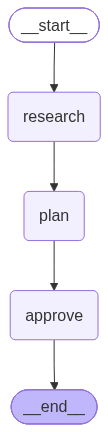

In [7]:
# ---- cell 7: build complete graph ----
from IPython.display import Image, display

# Build the graph
graph = StateGraph(TravelState)

# Add nodes
graph.add_node("research", research_agent)
graph.add_node("plan", planning_agent)
graph.add_node("approve", approval_gate)

# Add edges
graph.add_edge(START, "research")
graph.add_edge("research", "plan")
graph.add_edge("plan", "approve")
graph.add_edge("approve", END)

# Compile
app = graph.compile(checkpointer=MemorySaver())

print("Graph compiled successfully")

# ---- visualize ----
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Graph visualization: {e}")
    print("Graph structure: START -> research -> plan -> approve -> END")

## Phase 7: Running the Pipeline

Test the complete pipeline with different destinations.

In [8]:
# ---- cell 8: run pipeline ----
def run_travel_planner(destination, dates, budget, interests):
    """Run the complete travel planner pipeline."""
    print(f"\n{'='*60}")
    print(f"Travel Planner: {destination}")
    print(f"{'='*60}\n")
    
    # Create initial state
    state = TravelState(
        preferences=TravelPreferences(
            destination=destination,
            dates=dates,
            budget=budget,
            interests=interests
        ),
        research=ResearchFindings(),
        plan=TravelPlan(),
        approval_status="pending",
        feedback="",
        messages=[]
    )
    
    # Run pipeline (without HITL for demo)
    config = {"configurable": {"thread_id": "demo"}}
    
    # Run research and planning
    result = app.invoke(state, config)
    
    print("\nFinal Plan:")
    print(result["plan"].itinerary)
    
    return result

# ---- demo: run for Paris ----
if OLLAMA_OK:
    result = run_travel_planner(
        destination="Paris",
        dates="March 15-20, 2024",
        budget="moderate",
        interests=["history", "food", "art"]
    )
else:
    print("Running in offline mode (Ollama not available)")
    # Demo without LLM
    state = TravelState(
        preferences=TravelPreferences(
            destination="Paris",
            dates="March 15-20, 2024",
            budget="moderate",
            interests=["history", "food", "art"]
        ),
        research=ResearchFindings(),
        plan=TravelPlan(),
        approval_status="pending",
        feedback="",
        messages=[]
    )
    result = research_agent(state)
    result = planning_agent(result)
    print("\nFinal Plan:")
    print(result["plan"].itinerary)


Travel Planner: Paris

Researching Paris...
Interests: history, food, art

Found 3 attractions
Found 2 hotels
Found 3 restaurants
Planning itinerary for Paris...
Created 5 day plan
Requesting human approval...

Travel Plan for Paris:
Travel Plan: Paris
Dates: March 15-20, 2024
Budget: moderate

Day 1:
  Morning: Arrive in Paris
  Afternoon: Eiffel Tower - Iconic iron lattice tower
  Evening: Le Petit Cler (French bistro)

Day 2:
  Morning: Notre-Dame Cathedral - Medieval Gothic masterpiece
  Afternoon: Eiffel Tower - Iconic iron...

Final Plan:
Travel Plan: Paris
Dates: March 15-20, 2024
Budget: moderate

Day 1:
  Morning: Arrive in Paris
  Afternoon: Eiffel Tower - Iconic iron lattice tower
  Evening: Le Petit Cler (French bistro)

Day 2:
  Morning: Notre-Dame Cathedral - Medieval Gothic masterpiece
  Afternoon: Eiffel Tower - Iconic iron lattice tower
  Evening: La Tour d'Argent (Fine dining)

Day 3:
  Morning: Eiffel Tower - Iconic iron lattice tower
  Afternoon: Louvre Museum - Wo

## Phase 8: Multi-Destination Demo

Test the planner with different destinations.

In [9]:
# ---- cell 9: multi-destination demo ----
destinations = [
    ("Tokyo", "April 1-6, 2024", "moderate", ["culture", "food", "technology"]),
    ("New York", "May 10-15, 2024", "high", ["art", "food", "shopping"]),
]

for dest, dates, budget, interests in destinations:
    print(f"\n{'='*60}")
    print(f"Planning trip to {dest}")
    print(f"{'='*60}")
    
    state = TravelState(
        preferences=TravelPreferences(
            destination=dest,
            dates=dates,
            budget=budget,
            interests=interests
        ),
        research=ResearchFindings(),
        plan=TravelPlan(),
        approval_status="pending",
        feedback="",
        messages=[]
    )
    
    # Run research
    result = research_agent(state)
    
    # Run planning
    result = planning_agent(result)
    
    # Show abbreviated plan
    print(f"\n{dest} Plan Preview:")
    print(result["plan"].itinerary[:300] + "...")


Planning trip to Tokyo
Researching Tokyo...
Interests: culture, food, technology

Found 3 attractions
Found 2 hotels
Found 3 restaurants
Planning itinerary for Tokyo...
Created 5 day plan

Tokyo Plan Preview:
Travel Plan: Tokyo
Dates: April 1-6, 2024
Budget: moderate

Day 1:
  Morning: Arrive in Tokyo
  Afternoon: Senso-ji Temple - Ancient Buddhist temple
  Evening: Sushi Dai (Fresh sushi)

Day 2:
  Morning: Tokyo Skytree - Tallest tower in Japan
  Afternoon: Senso-ji Temple - Ancient Buddhist temple
  E...

Planning trip to New York
Researching New York...
Interests: art, food, shopping

Found 3 attractions
Found 2 hotels
Found 3 restaurants
Planning itinerary for New York...
Created 5 day plan

New York Plan Preview:
Travel Plan: New York
Dates: May 10-15, 2024
Budget: high

Day 1:
  Morning: Arrive in New York
  Afternoon: Statue of Liberty - Iconic American landmark
  Evening: Joe's Pizza (Classic NY slice)

Day 2:
  Morning: Times Square - Bright lights and Broadway
  Afternoon: 

## Summary

This notebook demonstrated:

1. **Multi-Agent Architecture** - Research agent + Planning agent
2. **Tool Integration** - Travel API tools for data retrieval
3. **Human-in-the-Loop** - Approval gate with interrupt/resume
4. **State Management** - TypedDict state with dataclasses
5. **LangGraph Pipeline** - Complete graph with conditional routing

## When to use this pattern
- Complex workflows requiring multiple specialized agents
- Applications needing human oversight before final output
- Systems where approval/feedback loops are required
- Multi-step processes with intermediate validation

## Next steps
- Add real travel APIs (Google Places, Booking.com)
- Implement persistent memory for user preferences
- Add streaming for real-time updates
- Build a web interface with Streamlit or Gradio